# Phase 1 Nutrient Analysis

### load packages, read in data, etc.

In [2]:
#load packages
library(lme4) #for linear mixed effects model
library(readr) #to read in data
library(tidyr)
library(emmeans) #for post hocs
library(esquisse) #interface for building plots
library(dplyr) #for data wrangling
library(nlme) #for linear mixed effects model
library(car) #for the Levene test
library(ggplot2) #for graphs
library(plotrix) #for standard error
library(performance) #model testing
library(lmtest) #another option than levene test for variance

Loading required package: Matrix


Attaching package: ‘tidyr’


The following objects are masked from ‘package:Matrix’:

    expand, pack, unpack


Warning message:
“package ‘emmeans’ was built under R version 4.4.3”
Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'

Warning message:
“package ‘dplyr’ was built under R version 4.4.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘nlme’


The following object is masked from ‘package:dplyr’:

    collapse


The following object is masked from ‘package:lme4’:

    lmList


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Loading required package: zoo


Attach

In [3]:
#set contrasts
options(contrasts = c("contr.sum","contr.poly")) #could also be contr.treatment for unequal groups sum
getOption("contrasts") 

[1] "contr.sum"  "contr.poly"

In [4]:
#Read in dataset, set column types
getwd()
setwd("/Users/sophiemontague/Desktop/MontagueORCC_repo/MontagueORCC/Oyster_Nutrient_Data/Phase1_Nutrient")

[1] "/Users/sophiemontague/Desktop/MontagueORCC_repo/MontagueORCC"

In [5]:
#read in % data
Tissue_Nutrient_df <- read_csv("Phase1_tissuenutrient_working.csv", 
                        col_types = cols(wt_percent_N = col_number(), 
                                         wt_percent_C = col_number()))
Shell_Nutrient_df <-read_csv("Phase1_shellnutrient_working.csv", 
                        col_types = cols(wt_percent_N = col_number(), 
                                         wt_percent_C = col_number()))

In [6]:
#filter out data points (errors/replicates)
#tissue
N_T_df <- Tissue_Nutrient_df%>%
  filter(N_exclude != "Y" | is.na(N_exclude))

C_T_df <- Tissue_Nutrient_df%>%
  filter(C_exclude != "Y" | is.na(C_exclude))

#shell
N_S_df <- Shell_Nutrient_df%>%
  filter(N_exclude != "Y" | is.na(N_exclude))

C_S_df <- Shell_Nutrient_df%>%
  filter(C_exclude != "Y" | is.na(C_exclude))

## % Nitrogen in Tissue

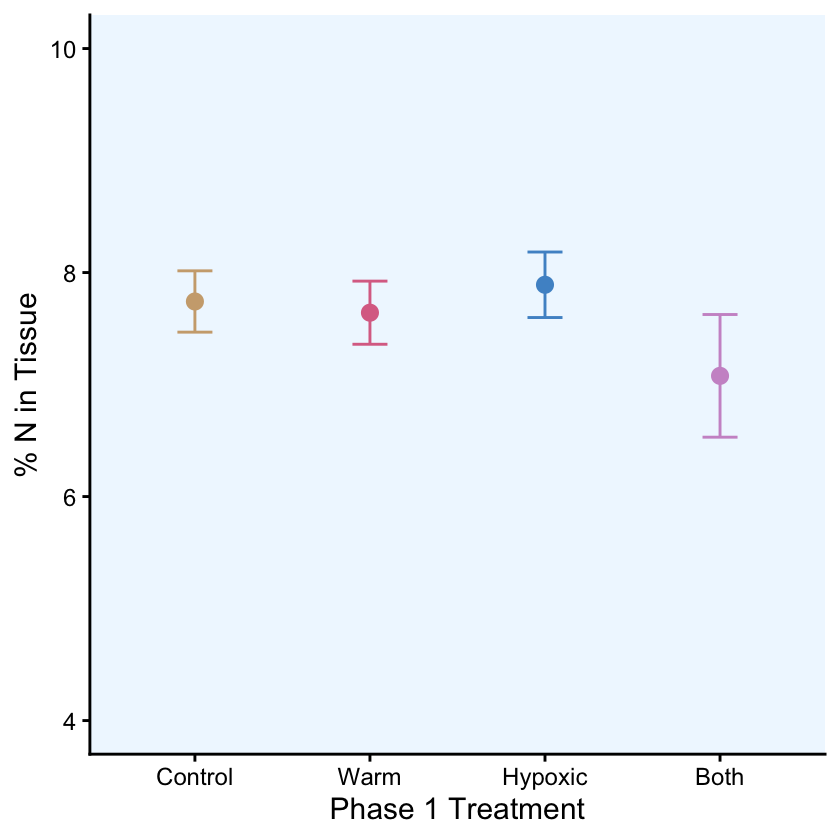

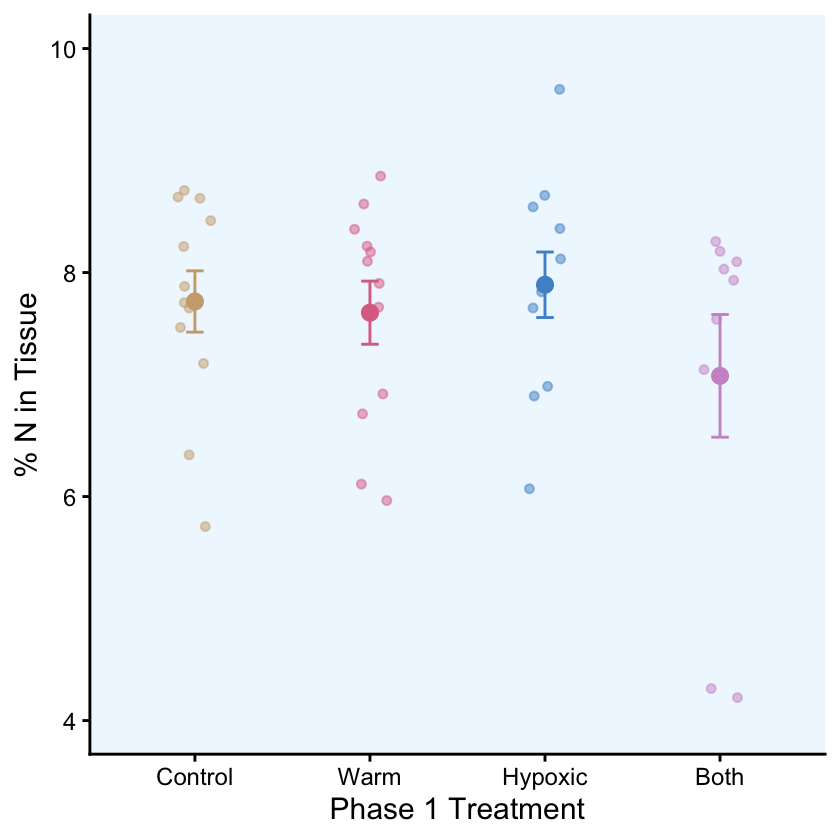

In [7]:
#summary stats
summary_stats <- N_T_df %>%
  group_by(Phase_1_treat) %>%
  summarize(
    mean_growth = mean(wt_percent_N, na.rm = TRUE),
    se_growth = std.error(wt_percent_N, na.rm = TRUE))
#reorder Phase_1_treat
summary_stats$Phase_1_treat <- factor(summary_stats$Phase_1_treat, 
                                      levels = c("Cont", "Warm","Hyp", "Both"))
#plot
ggplot(summary_stats, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  theme(panel.background = element_rect(fill = "aliceblue")) + #fill background light blue
  guides(color = "none") + # Remove legend for color
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
  labs(x = "Phase 1 Treatment", y = "% N in Tissue") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
  ylim(4,10)+
  theme(legend.position = "none") # Remove legend
#plot with raw data
ggplot(summary_stats, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_jitter(data = N_T_df,
              aes(x = Phase_1_treat, y = wt_percent_N, color = Phase_1_treat),
              width = 0.1, alpha = 0.5, size = 2) +
  geom_point(size = 4, position = position_dodge(0.9)) +
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.1, position = position_dodge(0.9)) +
  theme_classic(base_size = 18) +
  theme(panel.background = element_rect(fill = "aliceblue")) +
  guides(color = "none") +
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred",
                                "Cont" = "burlywood3", "Both" = "plum3")) +
  labs(x = "Phase 1 Treatment", y = "% N in Tissue") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control",
                              "Warm" = "Warm", "Both" = "Both")) +
  ylim(4, 10) +
  theme(legend.position = "none")

### Analysis

In [42]:
Nm1 <- lmer(wt_percent_N ~ Phase_1_DO*Phase_1_temp + 
              (1|Phase_1_rep_R), data = N_T_df, REML=TRUE)

aov_tab <- Anova(Nm1, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1926.3720992,1,19.57171,0.0000
Phase_1_DO,0.3595182,1,19.57171,0.5557
Phase_1_temp,1.7435381,1,19.57171,0.2019
Phase_1_DO:Phase_1_temp,1.0634180,1,19.57171,0.3150


#### No significant interactions

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,3,0.3181501,0.8121661
,40,NA,NA


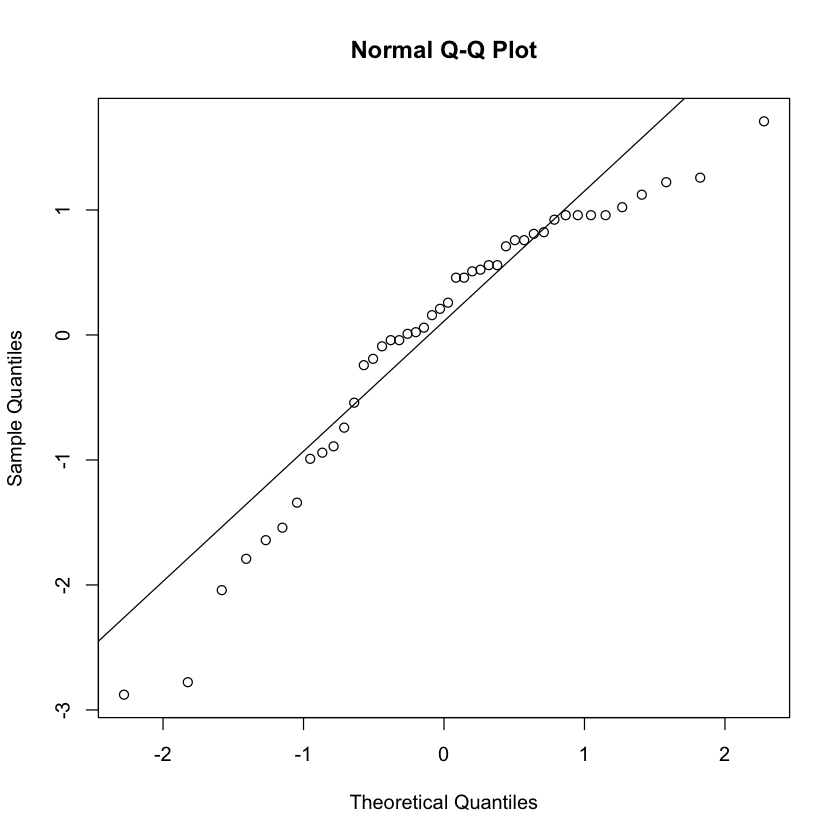

In [43]:
#diagnostics
leveneTest(wt_percent_N~Phase_1_DO*Phase_1_temp, N_T_df)
m1.e <- residuals(Nm1) 
qqnorm(m1.e)
qqline(m1.e)

## Carbon in Tissue

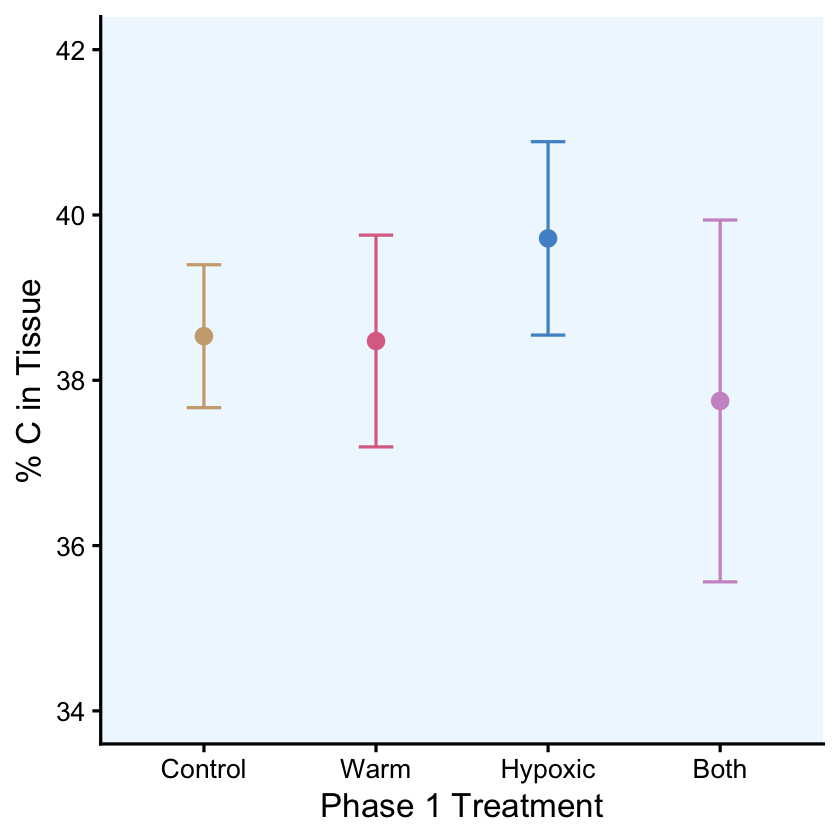

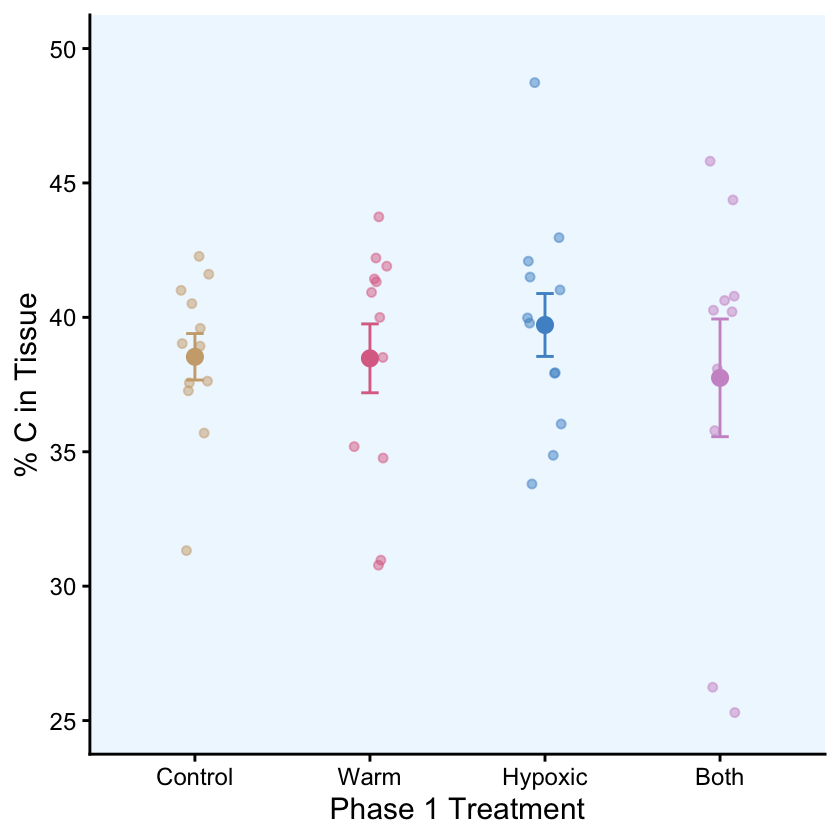

In [9]:
#summary stats
summary_stats <- C_T_df %>%
  group_by(Phase_1_treat) %>%
  summarize(
    mean_growth = mean(wt_percent_C, na.rm = TRUE),
    se_growth = std.error(wt_percent_C, na.rm = TRUE))

#reorder Phase_1_treat
summary_stats$Phase_1_treat <- factor(summary_stats$Phase_1_treat, 
                                      levels = c("Cont", "Warm","Hyp", "Both"))
#plot
ggplot(summary_stats, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 20) +
  theme(panel.background = element_rect(fill = "aliceblue")) + #fill background light grey
  guides(color = "none") + # Remove legend for color
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
  labs(x = "Phase 1 Treatment", y = "% C in Tissue") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
  ylim(34,42)+
  theme(legend.position = "none") # Remove legend
#plot with raw data
ggplot(summary_stats, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_jitter(data = C_T_df,
              aes(x = Phase_1_treat, y = wt_percent_C, color = Phase_1_treat),
              width = 0.1, alpha = 0.5, size = 2) +
  geom_point(size = 4, position = position_dodge(0.9)) +
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.1, position = position_dodge(0.9)) +
  theme_classic(base_size = 18) +
  theme(panel.background = element_rect(fill = "aliceblue")) +
  guides(color = "none") +
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred",
                                "Cont" = "burlywood3", "Both" = "plum3")) +
  labs(x = "Phase 1 Treatment", y = "% C in Tissue") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control",
                              "Warm" = "Warm", "Both" = "Both")) +
ylim(25, 50)+
  theme(legend.position = "none")

### Analysis

In [10]:
Cm1 <- lmer(log(wt_percent_C) ~ Phase_1_DO*Phase_1_temp +
              (1|Phase_1_rep_R), data = C_T_df, REML=TRUE)
aov_tab <-Anova(Cm1, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),3.519110e+04,1,19.72065,0.0000
Phase_1_DO,3.615743e-04,1,19.72065,0.9850
Phase_1_temp,7.808316e-01,1,19.72065,0.3875
Phase_1_DO:Phase_1_temp,5.671695e-01,1,19.72065,0.4603


#### No significant interactions

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,3,1.031584,0.388394
,42,NA,NA


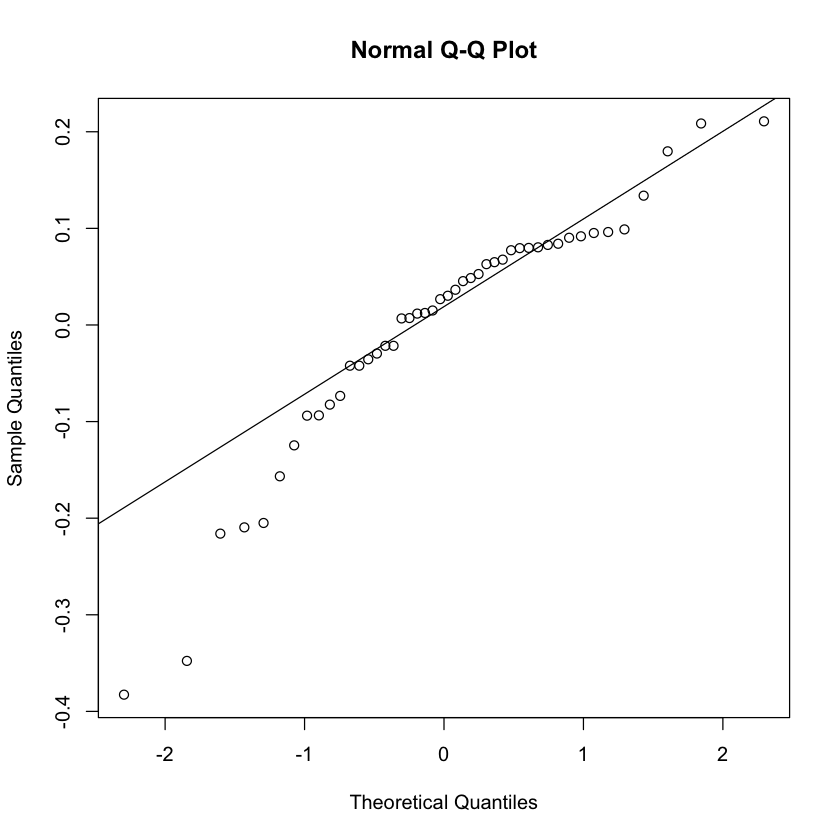

In [11]:
#diagnostics
leveneTest(log(wt_percent_C)~Phase_1_DO*Phase_1_temp, C_T_df)
m1.e <- residuals(Cm1) 
qqnorm(m1.e)
qqline(m1.e)

## Carbon:Nitrogen in Tissue

In [8]:
#read in data
Tissue_Nutrient_df <- read_csv("Phase1_tissuenutrient_working.csv", 
                               col_types = cols(wt_percent_N = col_number(), 
                                                wt_percent_C = col_number()))

#filter out exclusions for N and C
CN_T_df <- Tissue_Nutrient_df %>%
  filter( (is.na(N_exclude) | N_exclude != "Y") &
            (is.na(C_exclude) | C_exclude != "Y") )

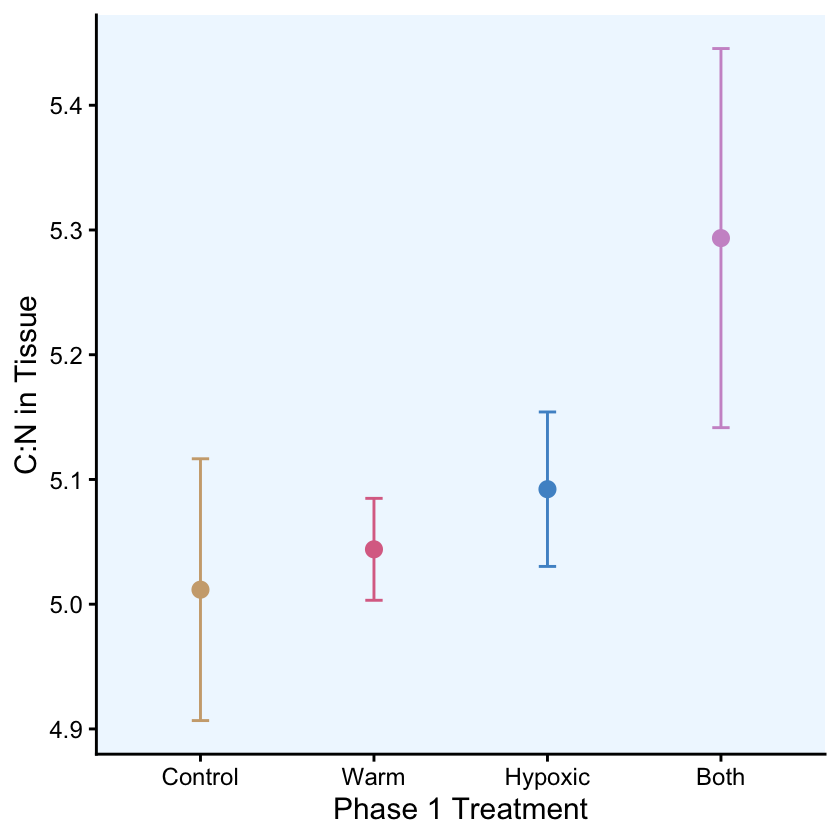

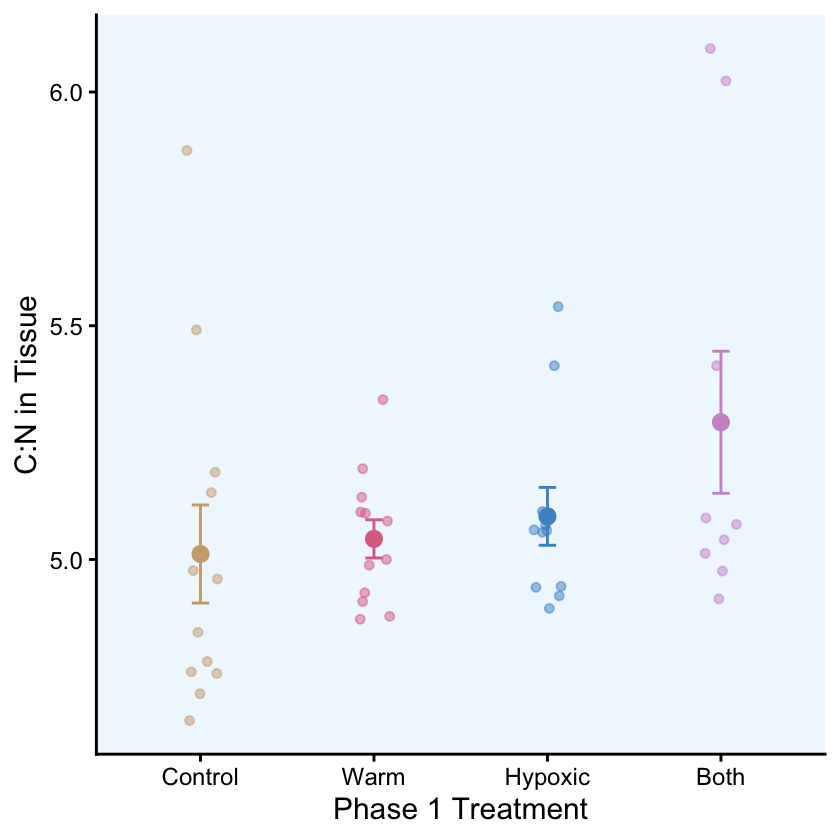

In [9]:
#summary stats
summary_stats <- CN_T_df %>%
  group_by(Phase_1_treat) %>%
  summarize(
    mean_growth = mean((wt_percent_C/wt_percent_N), na.rm = TRUE),
    se_growth = std.error((wt_percent_C/wt_percent_N), na.rm = TRUE))
#reorder Phase_1_treat
summary_stats$Phase_1_treat <- factor(summary_stats$Phase_1_treat, 
                                      levels = c("Cont", "Warm","Hyp", "Both"))
#plot
ggplot(summary_stats, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_point(size = 4, position = position_dodge(0.9)) +
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.1, position = position_dodge(0.9)) +
  theme_classic(base_size = 18) +
  theme(panel.background = element_rect(fill = "aliceblue")) +
  guides(color = "none") +
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred",
                                "Cont" = "burlywood3", "Both" = "plum3")) +
  labs(x = "Phase 1 Treatment", y = "C:N in Tissue") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control",
                              "Warm" = "Warm", "Both" = "Both")) +
  theme(legend.position = "none")

#plot with raw data
ggplot(summary_stats, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_point(size = 4, position = position_dodge(0.9)) +
  geom_jitter(data = CN_T_df,
              aes(x = Phase_1_treat, y = (wt_percent_C/wt_percent_N), color = Phase_1_treat),
              width = 0.1, alpha = 0.5, size = 2) +
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.1, position = position_dodge(0.9)) +
  theme_classic(base_size = 18) +
  theme(panel.background = element_rect(fill = "aliceblue")) +
  guides(color = "none") +
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred",
                                "Cont" = "burlywood3", "Both" = "plum3")) +
  labs(x = "Phase 1 Treatment", y = "C:N in Tissue") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control",
                              "Warm" = "Warm", "Both" = "Both")) +
  theme(legend.position = "none")


In [10]:
## C:N 
CNm1 <- lmer(log(wt_percent_C/wt_percent_N) ~ Phase_1_DO*Phase_1_temp + 
              (1|Phase_1_rep_R), data = CN_T_df, REML=TRUE)
aov_tab <- Anova(CNm1, test="F", type="III")
        #log transformed model is preferred as compared by AIC

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),3.443808e+04,1,19.57171,0.0000
Phase_1_DO,3.220187e+00,1,19.57171,0.0882
Phase_1_temp,1.621440e+00,1,19.57171,0.2178
Phase_1_DO:Phase_1_temp,6.350939e-01,1,19.57171,0.4351


In [19]:
#not running many interactions and also runs with bonferroni adjustment
emmeans(CNm1,specs = pairwise ~ Phase_1_DO, adjust = "none")
emmeans(CNm1,specs = pairwise ~ Phase_1_DO, adjust = "bonferroni")

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_1_DO emmean     SE   df lower.CL upper.CL
 Hypoxic      1.65 0.0131 21.8     1.62     1.67
 Normoxic     1.61 0.0117 17.2     1.59     1.64

Results are averaged over the levels of: Phase_1_temp 
Degrees-of-freedom method: kenward-roger 
Results are given on the log (not the response) scale. 
Confidence level used: 0.95 

$contrasts
 contrast           estimate     SE   df t.ratio p.value
 Hypoxic - Normoxic   0.0315 0.0176 19.6   1.794  0.0882

Results are averaged over the levels of: Phase_1_temp 
Degrees-of-freedom method: kenward-roger 
Results are given on the log (not the response) scale. 


NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_1_DO emmean     SE   df lower.CL upper.CL
 Hypoxic      1.65 0.0131 21.8     1.62     1.67
 Normoxic     1.61 0.0117 17.2     1.59     1.64

Results are averaged over the levels of: Phase_1_temp 
Degrees-of-freedom method: kenward-roger 
Results are given on the log (not the response) scale. 
Confidence level used: 0.95 

$contrasts
 contrast           estimate     SE   df t.ratio p.value
 Hypoxic - Normoxic   0.0315 0.0176 19.6   1.794  0.0882

Results are averaged over the levels of: Phase_1_temp 
Degrees-of-freedom method: kenward-roger 
Results are given on the log (not the response) scale. 


### Plotting significant factor

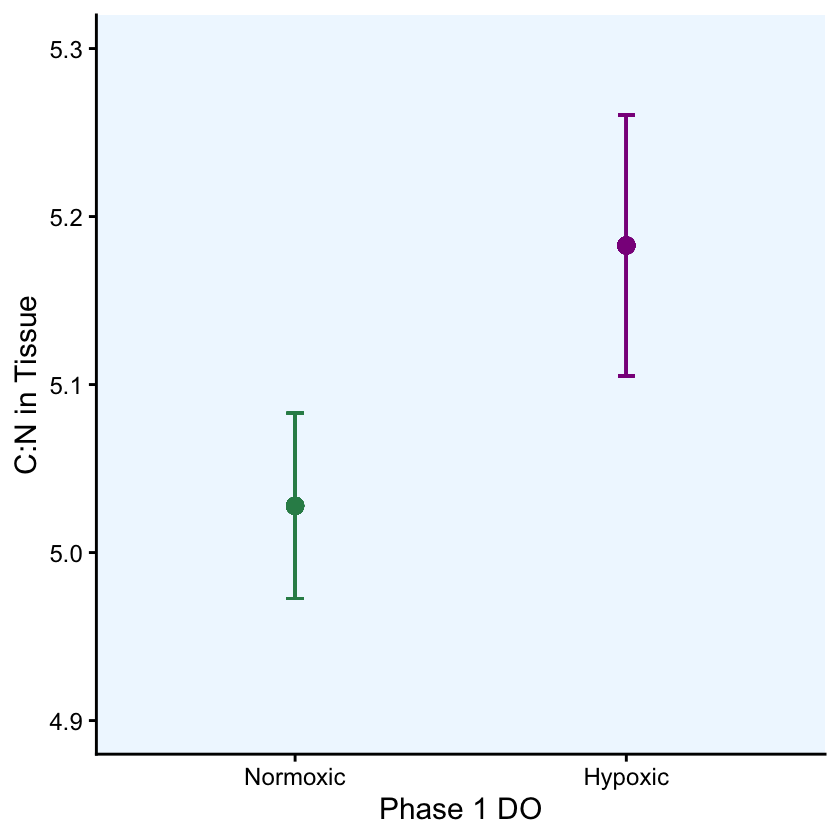

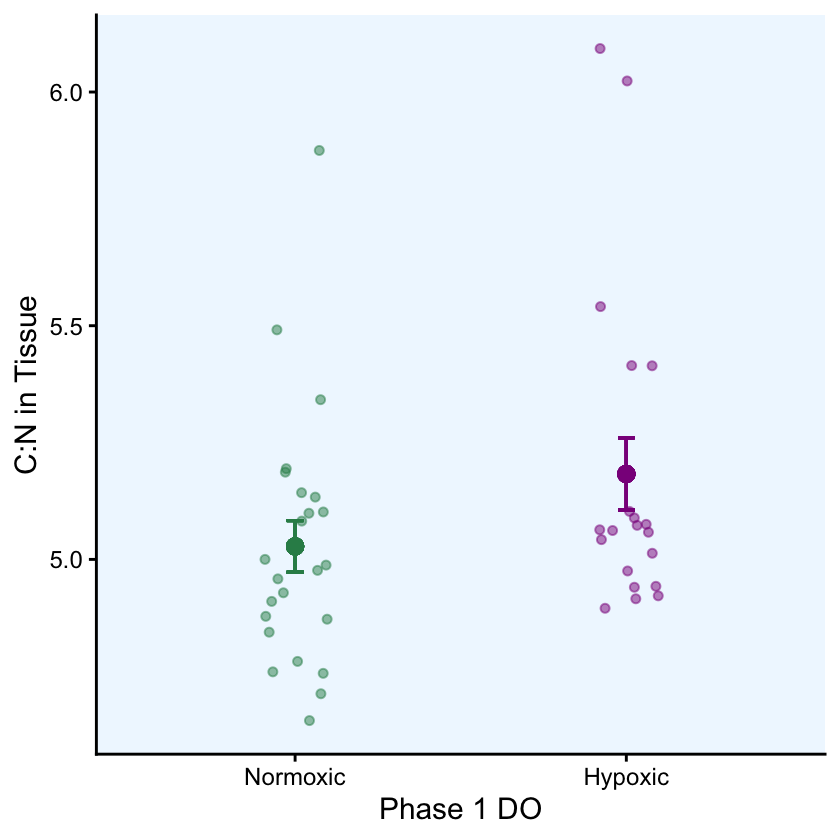

In [12]:
#summary stats
summary_stats <- CN_T_df %>%
  group_by(Phase_1_DO) %>%
  mutate(
    mean_cn = mean((wt_percent_C/wt_percent_N), na.rm = TRUE),
    se_cn = std.error((wt_percent_C/wt_percent_N), na.rm = TRUE))
#reorder
summary_stats$Phase_1_DO <- factor(summary_stats$Phase_1_DO, levels = c("Normoxic", "Hypoxic"))
#Tissue plot with mean and SD
ggplot(summary_stats, aes(x = Phase_1_DO, y = mean_cn, color = Phase_1_DO)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_cn - se_cn, ymax = mean_cn + se_cn), 
                width = 0.05, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  theme(panel.background = element_rect(fill = "aliceblue")) + #fill background light blue
  guides(color = "none") + # Remove legend for color
  scale_color_manual(values = c("Hypoxic" = "darkmagenta", "Normoxic" = "seagreen")) +
  labs(x = "Phase 1 DO", y = "C:N in Tissue") +
ylim(4.9, 5.3)+
  theme(legend.position = "none") # Remove legend

#Tissue plot with mean and SD
ggplot(summary_stats, aes(x = Phase_1_DO, y = mean_cn, color = Phase_1_DO)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
geom_jitter(data = CN_T_df,
              aes(x = Phase_1_DO, y = (wt_percent_C/wt_percent_N), color = Phase_1_DO),
              width = 0.1, alpha = 0.5, size = 2) +
  geom_errorbar(aes(ymin = mean_cn - se_cn, ymax = mean_cn + se_cn), 
                width = 0.05, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  theme(panel.background = element_rect(fill = "aliceblue")) + #fill background light blue
  guides(color = "none") + # Remove legend for color
  scale_color_manual(values = c("Hypoxic" = "darkmagenta", "Normoxic" = "seagreen")) +
  labs(x = "Phase 1 DO", y = "C:N in Tissue") +
  theme(legend.position = "none") # Remove legend

#### Oysters in hypoxia tended to store higher C:N than oysters in normoxia (p = 0.08)

In [8]:
colnames(N_T_df)

[1] "og_order"        "Sample_Name"     "Phase_1_treat"   "Phase_1_rep_R"  
 [5] "Phase_1_DO"      "Phase_1_temp"    "Linearcorr_d15N" "wt_percent_N"   
 [9] "N_notes"         "Linearcorr_d13C" "wt_percent_C"    "C_notes"        
[13] "N_exclude"       "C_exclude"

# δ15N in Oyster Tissue

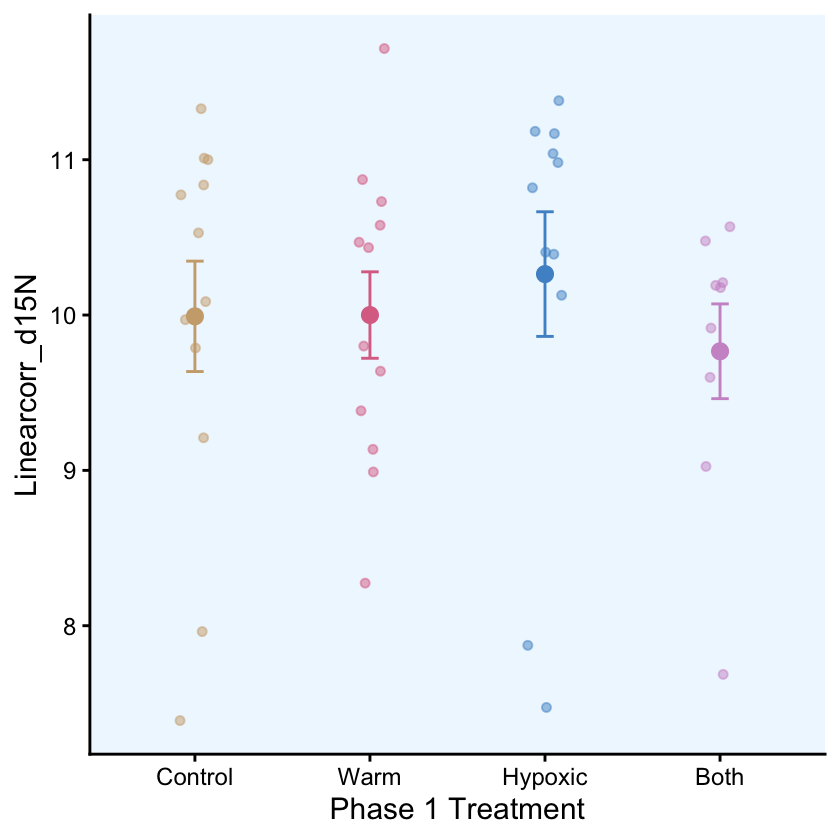

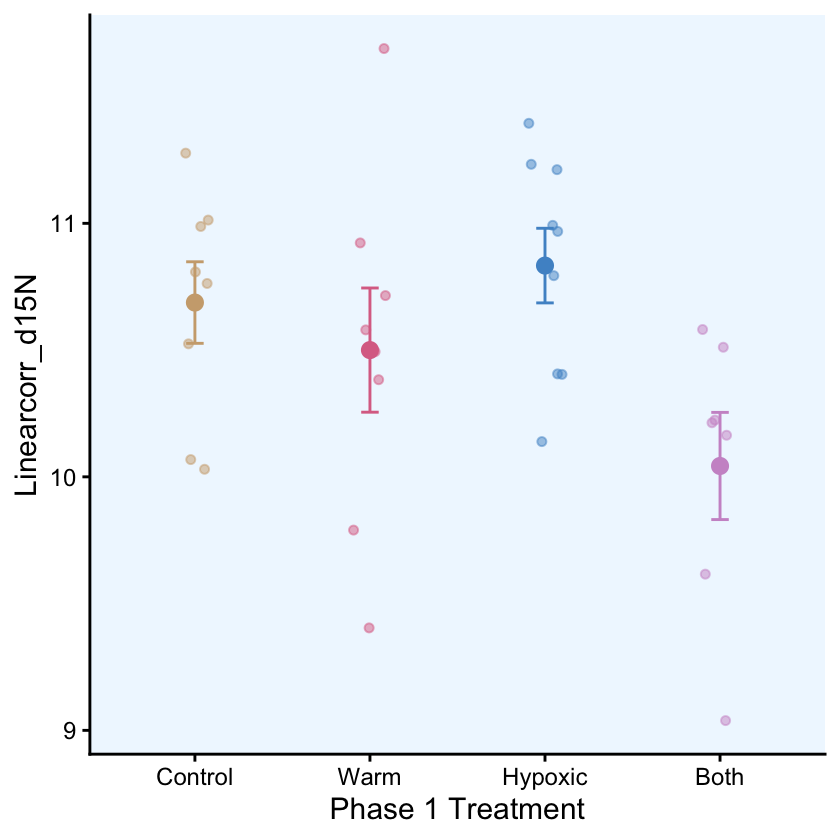

In [28]:
#summary stats
summary_stats <- N_T_df %>%
  group_by(Phase_1_treat) %>%
  summarize(
    mean_growth = mean(Linearcorr_d15N, na.rm = TRUE),
    se_growth = std.error(Linearcorr_d15N, na.rm = TRUE))
#reorder Phase_1_treat
summary_stats$Phase_1_treat <- factor(summary_stats$Phase_1_treat, 
                                      levels = c("Cont", "Warm","Hyp", "Both"))

#plot including ALL raw data
ggplot(summary_stats, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_jitter(data = N_T_df,
              aes(x = Phase_1_treat, y = Linearcorr_d15N, color = Phase_1_treat),
              width = 0.1, alpha = 0.5, size = 2) +
  geom_point(size = 4, position = position_dodge(0.9)) +
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.1, position = position_dodge(0.9)) +
  theme_classic(base_size = 18) +
  theme(panel.background = element_rect(fill = "aliceblue")) +
  guides(color = "none") +
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred",
                                "Cont" = "burlywood3", "Both" = "plum3")) +
  labs(x = "Phase 1 Treatment", y = "Linearcorr_d15N") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control",
                              "Warm" = "Warm", "Both" = "Both")) +
  theme(legend.position = "none")



#summary stats filtering out small peaks / data with higher error
summary_stats <- delta_N %>%
  group_by(Phase_1_treat) %>%
  summarize(
    mean_growth = mean(Linearcorr_d15N, na.rm = TRUE),
    se_growth = std.error(Linearcorr_d15N, na.rm = TRUE))
#reorder Phase_1_treat
summary_stats$Phase_1_treat <- factor(summary_stats$Phase_1_treat, 
                                      levels = c("Cont", "Warm","Hyp", "Both"))

#plot filtering out small peaks / data with higher error
ggplot(summary_stats, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_jitter(data = delta_N,
              aes(x = Phase_1_treat, y = Linearcorr_d15N, color = Phase_1_treat),
              width = 0.1, alpha = 0.5, size = 2) +
  geom_point(size = 4, position = position_dodge(0.9)) +
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.1, position = position_dodge(0.9)) +
  theme_classic(base_size = 18) +
  theme(panel.background = element_rect(fill = "aliceblue")) +
  guides(color = "none") +
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred",
                                "Cont" = "burlywood3", "Both" = "plum3")) +
  labs(x = "Phase 1 Treatment", y = "Linearcorr_d15N") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control",
                              "Warm" = "Warm", "Both" = "Both")) +
  theme(legend.position = "none")

### An increased δ15N in Oyster Tissue could be an indication of starvation. Low DO conditions have been linked to increased δ15N in Oyster Tissue (Patterson & Carmichael 2018).

## Analysis

In [14]:
colnames(N_T_df)

[1] "og_order"        "Sample_Name"     "Phase_1_treat"   "Phase_1_rep_R"  
 [5] "Phase_1_DO"      "Phase_1_temp"    "Linearcorr_d15N" "wt_percent_N"   
 [9] "N_notes"         "Linearcorr_d13C" "wt_percent_C"    "C_notes"        
[13] "N_exclude"       "C_exclude"

In [18]:
Nm1 <- lmer(Linearcorr_d15N ~ Phase_1_DO*Phase_1_temp +
              (1|Phase_1_rep_R), data = N_T_df, REML=TRUE)

aov_tab <- Anova(Nm1, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),3.287093e+03,1,19.59861,0.0000
Phase_1_DO,3.220591e-03,1,19.59861,0.9553
Phase_1_temp,4.938750e-01,1,19.59861,0.4905
Phase_1_DO:Phase_1_temp,5.280021e-01,1,19.59861,0.4760


In [19]:
View(N_T_df)

og_order,Sample_Name,Phase_1_treat,Phase_1_rep_R,Phase_1_DO,Phase_1_temp,Linearcorr_d15N,wt_percent_N,N_notes,Linearcorr_d13C,wt_percent_C,C_notes,N_exclude,C_exclude
<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
10,2024_Both01_Null_O6_T,Both,Both01,Hypoxic,Warm,9.6,8.3,NA,-23.4,40.8,NA,NA,NA
42,2024_Both01_Null_O98_T,Both,Both01,Hypoxic,Warm,7.7,8.2,small peak - error on δ15N will be higher,-24.8,44.4,NA,NA,NA
32,2024_Both02_Null_O13_T,Both,Both02,Hypoxic,Warm,10.5,7.1,NA,-23.7,35.8,NA,NA,NA
52,2024_Both02_Null_O14_T_C,Both,Both02,Hypoxic,Warm,10.6,8.0,NA,-23.3,40.6,NA,NA,NA
36,2024_Both03_Null_O22_T,Both,Both03,Hypoxic,Warm,9.9,4.2,small peak - error on δ15N will be higher,-19.6,25.3,NA,NA,NA
12,2024_Both05_Null_O33_T,Both,Both05,Hypoxic,Warm,10.2,7.6,NA,-22.9,38.1,NA,NA,NA
34,2024_Both05_Null_O38_T,Both,Both05,Hypoxic,Warm,10.2,7.9,NA,-23.8,40.2,NA,NA,NA
15,2024_Both06_Null_O45_T,Both,Both06,Hypoxic,Warm,10.2,8.1,NA,-24.0,40.3,NA,NA,NA
2,2024_Cont01_Null_W2_T,Cont,Cont01,Normoxic,Ambient,11.0,7.7,NA,-23.1,37.3,NA,NA,NA


In [22]:
delta_N <- N_T_df%>%
filter(is.na(N_notes))

In [23]:
delta_N

og_order,Sample_Name,Phase_1_treat,Phase_1_rep_R,Phase_1_DO,Phase_1_temp,Linearcorr_d15N,wt_percent_N,N_notes,Linearcorr_d13C,wt_percent_C,C_notes,N_exclude,C_exclude
<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
10,2024_Both01_Null_O6_T,Both,Both01,Hypoxic,Warm,9.6,8.3,NA,-23.4,40.8,NA,NA,NA
32,2024_Both02_Null_O13_T,Both,Both02,Hypoxic,Warm,10.5,7.1,NA,-23.7,35.8,NA,NA,NA
52,2024_Both02_Null_O14_T_C,Both,Both02,Hypoxic,Warm,10.6,8.0,NA,-23.3,40.6,NA,NA,NA
12,2024_Both05_Null_O33_T,Both,Both05,Hypoxic,Warm,10.2,7.6,NA,-22.9,38.1,NA,NA,NA
34,2024_Both05_Null_O38_T,Both,Both05,Hypoxic,Warm,10.2,7.9,NA,-23.8,40.2,NA,NA,NA
15,2024_Both06_Null_O45_T,Both,Both06,Hypoxic,Warm,10.2,8.1,NA,-24.0,40.3,NA,NA,NA
2,2024_Cont01_Null_W2_T,Cont,Cont01,Normoxic,Ambient,11.0,7.7,NA,-23.1,37.3,NA,NA,NA
7,2024_Cont01_Null_W6_T,Cont,Cont01,Normoxic,Ambient,10.0,7.9,NA,-23.0,37.6,NA,NA,NA
26,2024_Cont02_Null_W10_T,Cont,Cont02,Normoxic,Ambient,11.0,8.7,NA,-23.5,41.0,NA,NA,NA


In [24]:
Nm1 <- lmer(Linearcorr_d15N ~ Phase_1_DO*Phase_1_temp +
              (1|Phase_1_rep_R), data = delta_N, REML=TRUE)

aov_tab <- Anova(Nm1, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1.154157e+04,1,13.93777,0.0000
Phase_1_DO,6.321716e-01,1,13.93777,0.4399
Phase_1_temp,6.238881e+00,1,13.93777,0.0256
Phase_1_DO:Phase_1_temp,2.371649e+00,1,13.93777,0.1459


In [25]:
emmeans(Nm1,specs = pairwise ~ Phase_1_temp, adjust = "none")

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_1_temp emmean    SE   df lower.CL upper.CL
 Ambient        10.8 0.135 14.5    10.47     11.0
 Warm           10.3 0.142 13.5     9.97     10.6

Results are averaged over the levels of: Phase_1_DO 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast       estimate    SE   df t.ratio p.value
 Ambient - Warm    0.489 0.196 13.9   2.498  0.0256

Results are averaged over the levels of: Phase_1_DO 
Degrees-of-freedom method: kenward-roger 


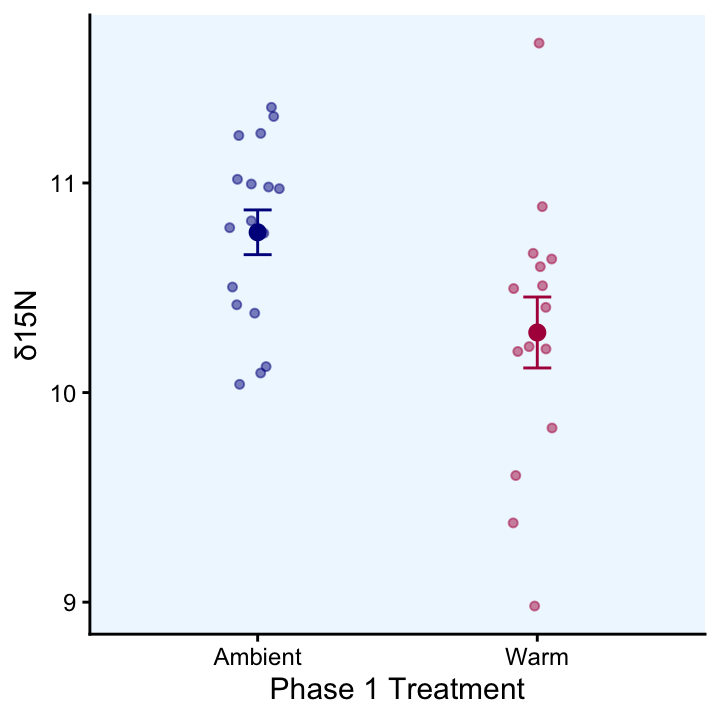

In [39]:
#format display for jupyter
options(repr.plot.width = 6, repr.plot.height = 6)

stats_s <- delta_N %>%
  group_by(Phase_1_temp) %>%
  summarise(
    mean_growth = mean(Linearcorr_d15N, na.rm = TRUE),
    se_growth = std.error(Linearcorr_d15N, na.rm = TRUE),
    .groups = "drop")

ggplot(stats_s, aes(
  x = Phase_1_temp,
  y = mean_growth,
  colour = Phase_1_temp)) +
  geom_jitter(data = delta_N,
    aes(
      x = Phase_1_temp,
      y = Linearcorr_d15N,
      colour = Phase_1_temp),
    inherit.aes = FALSE,
    width = 0.1,
    alpha = 0.5,
    size = 2) +
  geom_point(size = 4) +
  geom_errorbar(
    aes(
      ymin = mean_growth - se_growth,
      ymax = mean_growth + se_growth),
    width = 0.1) +
  scale_colour_manual(
    values = c("Warm" = "#B00149", "Ambient" = "darkblue")) +
  labs(
    x = "Phase 1 Treatment",
    y = "δ15N") +
  theme_classic(base_size = 18) +
  theme(
    panel.background = element_rect(fill = "aliceblue"),
    legend.position = "none")

### oysters in warm conditions had a lower δ15N than oysters in control conditions

### interesting because we expect increased δ15N if oysters are stressed due to catabolism of tissues (Patterson and Carmichael 2018)

# δ15N in Oyster Shell

In [66]:
#rename Linearcorr_d15N column
colnames(N_S_df)
N_S_df<-N_S_df%>%
rename(Linearcorr_d15N = 'Linear corr d15N')

[1] "og_order"         "Sample_Name"      "Phase_1_treat"    "Phase_1_rep_R"   
 [5] "Phase_1_DO"       "Phase_1_temp"     "Linear corr d15N" "wt_percent_N"    
 [9] "Linear corr d13C" "wt_percent_C"     "N_exclude"        "C_exclude"

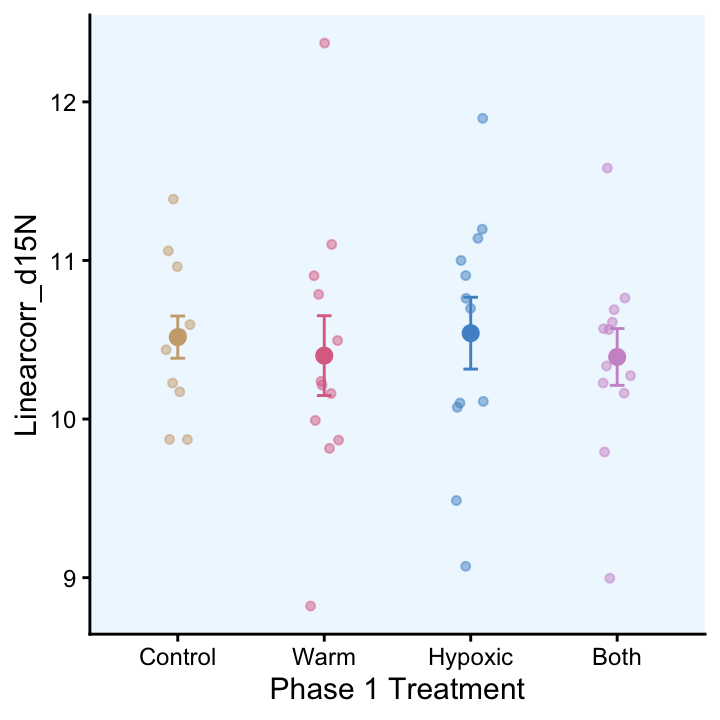

In [68]:
#summary stats
summary_stats <- N_S_df %>%
  group_by(Phase_1_treat) %>%
  summarize(
    mean_growth = mean(Linearcorr_d15N, na.rm = TRUE),
    se_growth = std.error(Linearcorr_d15N, na.rm = TRUE))
#reorder Phase_1_treat
summary_stats$Phase_1_treat <- factor(summary_stats$Phase_1_treat, 
                                      levels = c("Cont", "Warm","Hyp", "Both"))

#plot including ALL raw data
ggplot(summary_stats, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_jitter(data = N_S_df,
              aes(x = Phase_1_treat, y = Linearcorr_d15N, color = Phase_1_treat),
              width = 0.1, alpha = 0.5, size = 2) +
  geom_point(size = 4, position = position_dodge(0.9)) +
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.1, position = position_dodge(0.9)) +
  theme_classic(base_size = 18) +
  theme(panel.background = element_rect(fill = "aliceblue")) +
  guides(color = "none") +
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred",
                                "Cont" = "burlywood3", "Both" = "plum3")) +
  labs(x = "Phase 1 Treatment", y = "Linearcorr_d15N") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control",
                              "Warm" = "Warm", "Both" = "Both")) +
  theme(legend.position = "none")

In [70]:
Nm2 <- lmer(Linearcorr_d15N ~ Phase_1_DO*Phase_1_temp +
              (1|Phase_1_rep_R), data = N_S_df, REML=TRUE)

aov_tab <- Anova(Nm2, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),8.947241e+03,1,20,0.0000
Phase_1_DO,1.419044e-03,1,20,0.9703
Phase_1_temp,3.632752e-01,1,20,0.5535
Phase_1_DO:Phase_1_temp,5.676174e-03,1,20,0.9407


### No differences in δ15N in Oyster Shell